# JuPedSim Model Comparison Sweep

This notebook compares different pedestrian dynamics models using the same geometry and agent distribution.
 
**Models compared:**

- CollisionFreeSpeedModel: A velocity-based model where agents adjust speed to avoid overlaps.
- GeneralizedCentrifugalForceModel: A force-based model where agents exert "repulsive forces" on one another.

## 1. Load the base scenario

We load a standard corridor or room layout exported from the JuPedSim Web-UI.

In [ ]:
from jupedsim_scenario import load_scenario, run_scenario

scenario = load_scenario("scenarios/corridor_simple.json")
print(scenario.summary())

## 2. Execute the Sweep
We iterate through the available models and record the total evacuation time for each.

In [ ]:
models = [
    "CollisionFreeSpeedModel",
    "GeneralizedCentrifugalForceModel",
    "AnticipationVelocityModel",
    "SocialForceModel",
]
results_by_model = {}

for model in models:
    # Update the model type in the scenario object
    scenario.set_model_type(model)

    # Run the simulation
    r = run_scenario(scenario)
    results_by_model[model] = r.evacuation_time

    print(f"Model: {model} | Evacuation Time: {r.evacuation_time:.2f}s")
    r.cleanup()  # Free up resources

## 3. Visualizing Results
Comparison of how the mathematical underlying "logic" of the agents affects the overall efficiency.

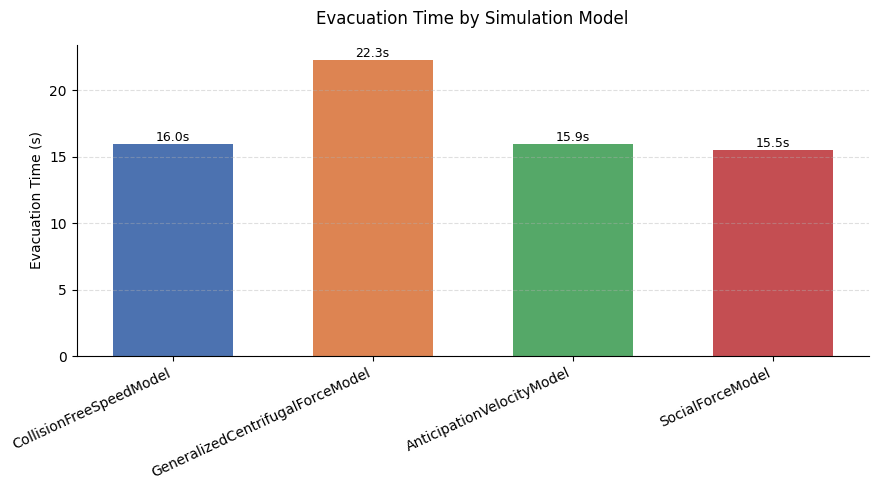

In [11]:
import matplotlib.pyplot as plt

models = list(results_by_model.keys())
times = list(results_by_model.values())

plt.figure(figsize=(9, 5))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bars = plt.bar(models, times, color=colors[:len(models)], width=0.6)
plt.ylabel("Evacuation Time (s)")
plt.title("Evacuation Time by Simulation Model", pad=15)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}s",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()